In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


2026-04-22 01:56:23.460879: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 01:56:23.470694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776797783.482333   73244 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776797783.486213   73244 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776797783.495645   73244 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [3]:

BASE_PATHHASIL = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/Final/imgsize128/norm/dwt/"

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_tow_ids():

    inputs = layers.Input(shape=(64, 64, 3))

    # ===== Block A =====
    x = layers.SeparableConv2D(32, (3,3), padding="same")(inputs)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # ===== Block B (Residual) =====
    shortcut = layers.Conv2D(64, (1,1), padding="same")(x)

    x = layers.SeparableConv2D(64, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # ===== Block C =====
    x = layers.SeparableConv2D(128, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ===== Dense Head =====
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [5]:

train_data = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_test_dwt.npz"))
val_data   = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_validation_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

X_val   = val_data["X"]
y_val   = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

(26329, 64, 64, 3) (26329,)
(24734, 64, 64, 3) (24734,)
(11284, 64, 64, 3) (11284,)


In [6]:
tf.keras.backend.clear_session()

model = build_cnn_tow_ids()
model.summary()


I0000 00:00:1776797786.628616   73244 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3180 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │        155 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 32, 32,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 32, 32,    │      8,896 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 228,348 (891.98 KB)

 Trainable params: 227,900 (890.23 KB)

 Non-trainable params: 448 (1.75 KB)

 Total params: 228,348 (891.98 KB)
 Trainable params: 227,900 (890.23 KB)
 Non-trainable params: 448 (1.75 KB)

In [7]:


history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    
)


Epoch 1/50


I0000 00:00:1776797789.812668   73362 service.cc:152] XLA service 0x72a094003f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776797789.812685   73362 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-04-22 01:56:29.868359: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776797790.208712   73362 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-04-22 01:56:31.277272: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332', 484 bytes spill stores, 484 bytes spill loads

2026-04-22 01:56:31.767557: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

819/823 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2163

2026-04-22 01:56:43.890959: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332_0', 36 bytes spill stores, 36 bytes spill loads

2026-04-22 01:56:44.194103: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332', 488 bytes spill stores, 488 bytes spill loads

2026-04-22 01:56:44.740260: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2183', 28 bytes spill stores, 32 bytes spill loads

2026-04-22 01:56:44.792372: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2185', 28 bytes spill stores, 32 bytes spill loads

2026-04-22 01:56:44.816947: I extern

823/823 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9152 - loss: 0.2160

2026-04-22 01:56:53.715907: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151_0', 36 bytes spill stores, 36 bytes spill loads

2026-04-22 01:56:54.246730: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 488 bytes spill stores, 488 bytes spill loads



823/823 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.9523 - loss: 0.1386 - val_accuracy: 0.9579 - val_loss: 0.1383
Epoch 2/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9744 - loss: 0.0837 - val_accuracy: 0.9612 - val_loss: 0.1515
Epoch 3/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9785 - loss: 0.0703 - val_accuracy: 0.8573 - val_loss: 0.3695
Epoch 4/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9829 - loss: 0.0573 - val_accuracy: 0.9414 - val_loss: 0.1597
Epoch 5/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9845 - loss: 0.0496 - val_accuracy: 0.9475 - val_loss: 0.1418
Epoch 6/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9867 - loss: 0.0448 - val_accuracy: 0.9840 - val_loss: 0.0545
Epoch 7/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9890 - loss: 0.0383 - val_accuracy: 0.8310 - val_loss: 0.6053
Epoch 8/50
823/823 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9900 - loss: 0.0349 - val_accuracy: 0.9922 - va

In [8]:
# === TEST ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("\n=== TEST RESULT ===")
print("Loss :", test_loss)
print("Acc  :", test_acc)

764/773 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0352

2026-04-22 02:01:31.691308: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151_0', 36 bytes spill stores, 36 bytes spill loads

2026-04-22 02:01:32.122091: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 488 bytes spill stores, 488 bytes spill loads



773/773 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9906 - loss: 0.0712

=== TEST RESULT ===
Loss : 0.07124211639165878
Acc  : 0.9906201958656311


Threshold 0.5

In [9]:
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)


773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


Confusion Matrix + Nilai Dasar

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)


TP: 11357
FP: 22
TN: 13145
FN: 210


Hitung Semua Metric Sesuai Persamaan Paper

In [11]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
fmeasure  = 2 * precision * recall / (precision + recall)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"Precision: {precision:.6f}")
print(f"F-measure: {fmeasure:.6f}")



=== Metrics (Threshold 0.5) ===
Accuracy : 0.990620
Recall   : 0.981845
Precision: 0.998067
F-measure: 0.989889


In [12]:
# === Confusion values sudah ada ===
# tp, tn, fp, fn

accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn + 1e-12)
precision = tp / (tp + fp + 1e-12)
f1        = 2 * precision * recall / (precision + recall + 1e-12)

# tambahan
fpr = fp / (fp + tn + 1e-12)
fnr = fn / (fn + tp + 1e-12)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1        : {f1:.6f}")
print(f"FPR       : {fpr:.6f}")
print(f"FNR       : {fnr:.6f}")
print(f"FP        : {fp}")
print(f"FN        : {fn}")



=== Metrics (Threshold 0.5) ===
Accuracy  : 0.990620
Precision : 0.998067
Recall    : 0.981845
F1        : 0.989889
FPR       : 0.001671
FNR       : 0.018155
FP        : 22
FN        : 210



=== Metrics (Threshold 0.5) ===
Accuracy  : 0.981726
Precision : 0.968790
Recall    : 0.992911
F1        : 0.980702
FPR       : 0.028101
FNR       : 0.007089
FP        : 370
FN        : 82

ROC Curve + AUC (Persamaan 13)

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.6f}")


AUC: 0.998098


Plot ROC

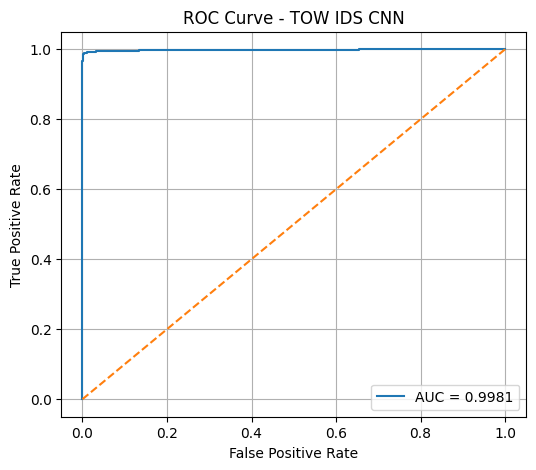

In [14]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TOW IDS CNN")
plt.legend()
plt.grid()
plt.show()


Plot Confusion Matrix

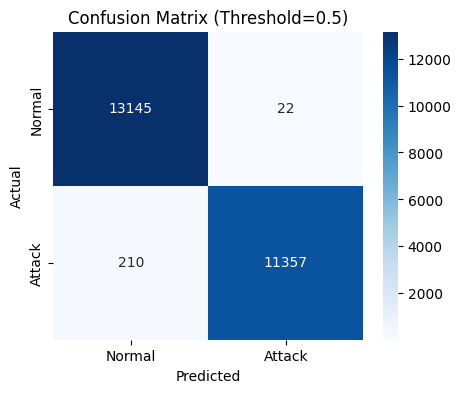

In [15]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted")                                                                                         
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold=0.5)")
plt.show()


Plot Confusion Matrix

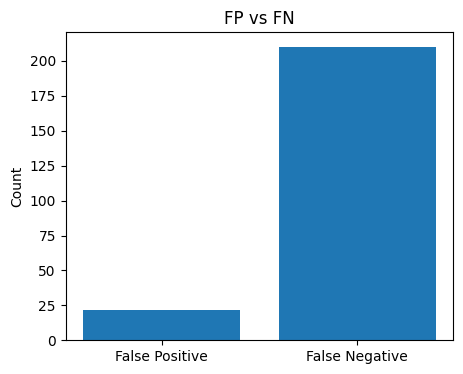

In [16]:
plt.figure(figsize=(5,4))
plt.bar(["False Positive", "False Negative"], [fp, fn])
plt.title("FP vs FN")
plt.ylabel("Count")
plt.show()


Plot FP vs FN

In [17]:
import numpy as np

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden):", best_threshold)


Best Threshold (Youden): 0.19266234


In [18]:
youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.19266234


In [19]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

In [21]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
fmeasure  = 2 * precision * recall / (precision + recall)

print("\n=== Metrics BEST THRESHOLD ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"Precision: {precision:.6f}")
print(f"F-measure: {fmeasure:.6f}")


=== Metrics BEST THRESHOLD ===
Accuracy : 0.992440
Recall   : 0.988156
Precision: 0.995645
F-measure: 0.991886


Threshold Optimization (Youden Index)

In [22]:
y_pred_opt = (y_prob >= best_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)

tn2, fp2, fn2, tp2 = cm_opt.ravel()

acc_opt = (tp2 + tn2) / (tp2 + tn2 + fp2 + fn2)

print("\nAccuracy Optimal:", acc_opt)



Accuracy Optimal: 0.9924395568852592


Detection Speed

In [23]:
import time

start = time.time()
_ = model.predict(X_test[:256])
latency = (time.time() - start) / 256

print("Inference time per sample:", latency)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Inference time per sample: 0.00033028051257133484
